In [52]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2

In [60]:
def perspect_transform(img, src, dst):

    # Get transform matrix using cv2.getPerspectivTransform()
    M = cv2.getPerspectiveTransform(src, dst)
    # Warp image using cv2.warpPerspective()
    # keep same size as input image
    warped = cv2.warpPerspective(img, M, (img.shape[1], img.shape[0]))
    # Return the result
    return warped

def navigable_thresh(img, rgb_thresh=(170, 170, 170)):
    # Create an array of zeros same xy size as img, but single channel
    color_select = np.zeros_like(img[:,:,0])
    # Require that each pixel be above all thre threshold values in RGB
    # above_thresh will now contain a boolean array with "True"
    # where threshold was met
    above_thresh = (img[:,:,0] > rgb_thresh[0]) \
                & (img[:,:,1] > rgb_thresh[1]) \
                & (img[:,:,2] > rgb_thresh[2])
    # Index the array of zeros with the boolean array and set to 1
    color_select[above_thresh] = 1
    # Return the binary image
    return color_select
 
def rock_thresh(img):
    """Check the image for yellow rocks using OpenCV for determining the
    mask required.
    :param img: Numpy 3d array (x, y, RGB layers)
    :return: Numpy 2d array (x, y) of the binary image
    """
    # Convert BGR to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV, 3)
    
    # Define range of yellow colors in HSV
    lower_yellow = np.array([20, 150, 100], dtype='uint8')
    upper_yellow = np.array([50, 255, 255], dtype='uint8')
    
    # Threshold the HSV image to get only yellow colors
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    return mask 


def obstacle_thresh(img, rgb_thresh=(160, 160, 160)):
    """Identify the image pixels that are above the provided threshold. Each
    threshold value can range between 0 and 255, with 160 doing a nice job
    of identifying ground pixels only.
    :param img: Numpy 3d array (x, y, RGB layers)
    :param rgb_threh: 3 item tuple of integers specifying the threshold for
        excluding pixel values
    :return: Numpy 2d array (x, y) of the binary image
    """
    # Create an array of zeros with the same xy size as img, but single channel
    color_select = np.zeros_like(img[:,:,0])
    # Require that each pixel be below all three threshold values in rbg_thresh.
    #   Values below the threshold will now contain a boolean array with TRUE.
    below_thresh = ((img[:,:,0] < rgb_thresh[0]) &
                    (img[:,:,1] < rgb_thresh[1]) &
                    (img[:,:,2] < rgb_thresh[2]))
    # Index the array of zeros with the boolean array and set to 1
    color_select[below_thresh] = 1
    return color_select



def removeOutPixels(ypos2,xpos2,binaryImage):
    ypos1, xpos1 = binaryImage.nonzero()

    xpos3 = np.zeros(0)
    ypos3 = np.zeros(0)

    for j in range(0, ypos2.size-1):  
        isIN = 0
        for i in range(0, ypos1.size-1):
            if (ypos2[j]  == ypos1[i]) & (xpos2[j] == xpos1[i]):
                isIN = 1         
                break
        if(isIN == 1):
            xpos3 = np.append(xpos3, xpos1[i])
            ypos3 = np.append(ypos3, ypos1[i])
            #count = count + 1

    #return ypos3,xpos3
    return ypos1,xpos1


binaryImage = mpimg.imread('map_bw.png')


def rover_coords(binary_img):
     # Identify nonzero pixels
    ypos, xpos = binary_img.nonzero()
    
    #remove outPixels
    
    #ypos, xpos = removeOutPixels(ypos, xpos,binaryImage)
    
    # Calculate pixel positions with reference to the rover position being at the 
    # center bottom of the image.  
    x_pixel = -(ypos - binary_img.shape[0]).astype(np.float32)
    y_pixel = -(xpos - binary_img.shape[0]).astype(np.float32)
    
    return x_pixel, y_pixel


def to_polar_coords(xpix, ypix):
    # Calculate distance to each pixel
    dist = np.sqrt(xpix**2 + ypix**2)
    # Calculate angle using arctangent function
    angles = np.arctan2(ypix, xpix)
    return dist, angles




############################# helper functions to be used in pix_to_world #####################################

# this function rotates group of pixels 
# whose y coordinates are in  ypix array and x coordinates are in xpix array
def rotate_pix(xpix, ypix, yaw):
    # Convert yaw to radians
    yaw_rad = yaw * np.pi / 180
    
    # from rotation matrix
    #
    #   [  xpix_rotated  ]       [   cos(rotational_angle)           -sin(rotational_angle) ] [ xpix ]
    #   [                ]   =   [                                                          ] [      ]
    #   [  ypix_rotated  ]       [   sin(rotational_angle)           cos(rotational_angle)  ] [ ypix ]
    
    xpix_rotated = (xpix * np.cos(yaw_rad)) - (ypix * np.sin(yaw_rad))                         
    ypix_rotated = (xpix * np.sin(yaw_rad)) + (ypix * np.cos(yaw_rad))
    
    # Return the result  
    return xpix_rotated, ypix_rotated




# this function takes pixels after rotatation by yaw angle and transfor axes to to point (xpos,ypos)
def translate_pix(xpix_rot, ypix_rot, xpos, ypos, scale): 
    # Apply a scaling and a translation
    xpix_translated = (xpix_rot / scale) + xpos
    ypix_translated = (ypix_rot / scale) + ypos
    
    # Return the result  
    return xpix_translated, ypix_translated


###############################################################################################################

# this function applies rotation by yaw angle , axes transfer and clipping
def pix_to_world(xpix, ypix, xpos, ypos, yaw, world_size, scale):
    # Apply rotation by yaw angle
    xpix_rot, ypix_rot = rotate_pix(xpix, ypix, yaw)
    
    # Apply axes transfer to point (xpos,ypos)
    xpix_tran, ypix_tran = translate_pix(xpix_rot, ypix_rot, xpos, ypos, scale)
    
    # Clip to world_size
    x_pix_world = np.clip(np.int_(xpix_tran), 0, world_size - 1)
    y_pix_world = np.clip(np.int_(ypix_tran), 0, world_size - 1)
    
    # Return the result
    return x_pix_world, y_pix_world

Xpos = [32.75104328] Ypos = [92.46921797] Yaw = [27.22892868]


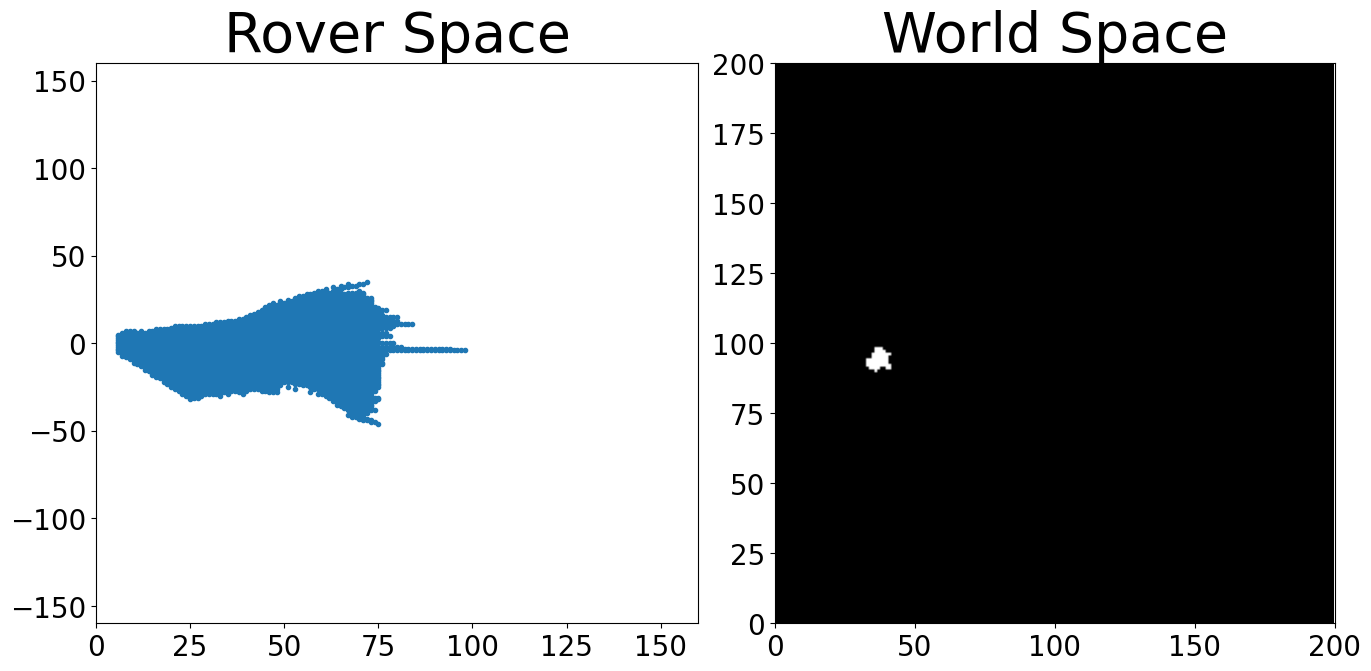

In [61]:
# Read in the sample image
image = mpimg.imread('sample.jpg')


# Rover yaw values will come as floats from 0 to 360
# Position values will range from 20 to 180 to  avoid the edges in a 200 x 200 pixel world
# Generate random values for yaw , xpos , ypos for rover
rover_yaw = np.random.random(1)*360
rover_xpos = np.random.random(1)*160 + 20
rover_ypos = np.random.random(1)*160 + 20



# Define calibration box in source (actual) and destination (desired) coordinates
# These source and destination points are defined to warp the image
# to a grid where each 10x10 pixel square represents 1 square meter
dst_size = 5 
# Set a bottom offset to account for the fact that the bottom of the image 
# is not the position of the rover but a bit in front of it
bottom_offset = 6


# 1) Define source and destination points for perspective transform
source = np.float32([[14, 140], [301 ,140],[200, 96], [118, 96]])
destination = np.float32([[image.shape[1]/2 - dst_size, image.shape[0] - bottom_offset],
                  [image.shape[1]/2 + dst_size, image.shape[0] - bottom_offset],
                  [image.shape[1]/2 + dst_size, image.shape[0] - 2*dst_size - bottom_offset], 
                  [image.shape[1]/2 - dst_size, image.shape[0] - 2*dst_size - bottom_offset],
                  ])


# 2) Apply perspective transform
warped = perspect_transform(image, source, destination)


# 3) Apply color threshold to identify navigable terrain sample
navigable = navigable_thresh(img=warped, rgb_thresh=(160, 160, 160)) 
obstacles = obstacle_thresh(img=warped, rgb_thresh=(140, 140, 140))
rock_samples = rock_thresh(img=warped)



# 5) Convert map image pixel values to rover-centric coords
# Extract navigable terrain pixels
navigable_xpix, navigable_ypix = rover_coords(navigable)
obstacles_xpix, obstacles_ypix = rover_coords(obstacles)
rocks_xpix, rocks_ypix = rover_coords(rock_samples)


# 6) Convert rover-centric pixel values to world coordinates
# Generate 200 x 200 pixel worldmap
worldmap = np.zeros((200, 200))
scale = dst_size*2


# Get navigable pixel positions in world coords
x_world, y_world = pix_to_world( navigable_xpix, navigable_ypix    , rover_xpos, rover_ypos    ,rover_yaw   ,worldmap.shape[0], scale)


# Add pixel positions to worldmap
worldmap[y_world, x_world] += 1

print('Xpos =', rover_xpos, 'Ypos =', rover_ypos, 'Yaw =', rover_yaw)


# Plot the map in rover-centric coords

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
f.tight_layout()
ax1.plot(navigable_xpix, navigable_ypix, '.')
ax1.set_title('Rover Space', fontsize=40)
ax1.set_ylim(-160, 160)
ax1.set_xlim(0, 160)
ax1.tick_params(labelsize=20)

ax2.imshow(worldmap, cmap='gray')
ax2.set_title('World Space', fontsize=40)
ax2.set_ylim(0, 200)
ax2.tick_params(labelsize=20)
ax2.set_xlim(0, 200)


plt.subplots_adjust(left=0.1, right=1, top=0.9, bottom=0.1)
plt.show() # Uncomment if running on your local machine

NameError: name 'colorsel' is not defined

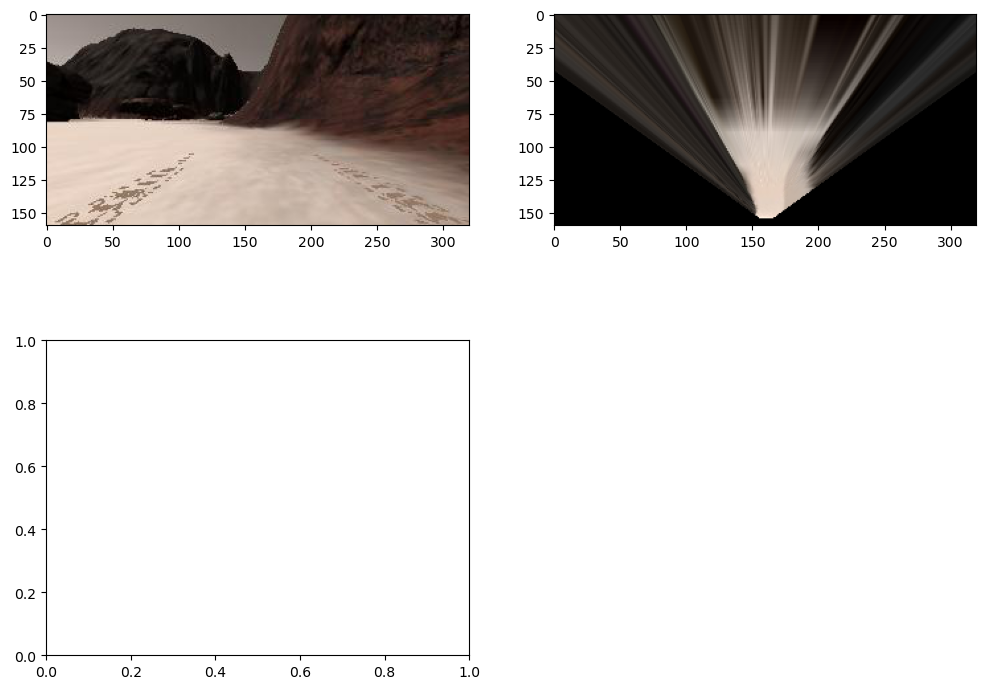

In [22]:
image = mpimg.imread('angle_example.jpg')


distances, angles = to_polar_coords(navigable_xpix, navigable_ypix) # Convert to polar coords
avg_angle = np.mean(angles) # Compute the average angle
avg_angle_degrees = avg_angle * 180/np.pi
steering = np.clip(avg_angle_degrees, -15, 15)

# Do some plotting
fig = plt.figure(figsize=(12,9))
plt.subplot(221)
plt.imshow(image)
plt.subplot(222)
plt.imshow(warped)
plt.subplot(223)
plt.imshow(colorsel, cmap='gray')
plt.subplot(224)
plt.plot(xpix, ypix, '.')
plt.ylim(-160, 160)
plt.xlim(0, 160)
arrow_length = 100
x_arrow = arrow_length * np.cos(avg_angle)
y_arrow = arrow_length * np.sin(avg_angle)
plt.arrow(0, 0, x_arrow, y_arrow, color='red', zorder=2, head_width=10, width=2)
plt.show()

In [ ]:
worldmap = np.zeros((200, 200, 3), dtype=np.float32)

scale = dst_size * 2 + 3
xpos, ypos = (100,100)
yaw = 200
worldmap_size = worldmap.shape[0]

navigable = navigable_thresh(img=warped, rgb_thresh=(160, 160, 160)) 
obstacles = obstacle_thresh(img=warped, rgb_thresh=(140, 140, 140))
rock_samples = rock_thresh(img=warped)
    
navigable_xpix, navigable_ypix = rover_coords(navigable)
obstacles_xpix, obstacles_ypix = rover_coords(obstacles)
rocks_xpix, rocks_ypix = rover_coords(rock_samples)


navigable_x_world, navigable_y_world = pix_to_world(navigable_xpix, navigable_ypix, xpos, ypos, yaw, worldmap_size, scale)
obstacles_x_world, obstacles_y_world = pix_to_world(obstacles_xpix, obstacles_ypix, xpos, ypos, yaw, worldmap_size, scale)
rocks_x_world, rocks_y_world = pix_to_world(rocks_xpix, rocks_ypix, xpos, ypos, yaw, worldmap_size, scale)

# 7) Update Rover worldmap (to be displayed on right side of screen)
worldmap[obstacles_y_world, obstacles_x_world, 0] += 1
worldmap[rocks_y_world, rocks_x_world, 1] = 255
worldmap[navigable_y_world, navigable_x_world, 2] += 1

# display vision_image
plt.imshow(worldmap, cmap='gray')
plt.show()